# Module 2: Epidemic Modeling Template

## Team Members:
Amelia Luongo and Isabella Imburgia

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

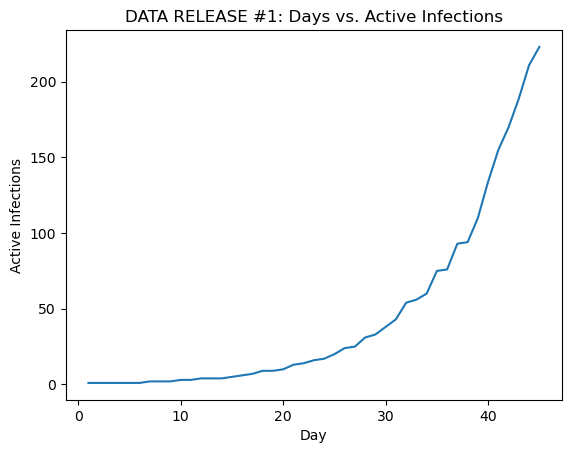

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# creating a graph that shows the number of active infections each day
df = pd.read_csv("/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv")

# Plot day vs active infections
plt.figure()
plt.plot(df["day"], df["active reported daily cases"])
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("DATA RELEASE #1: Days vs. Active Infections")
plt.show()


The initial infection spreads very slowly. There is only one active infection for the first 6 days of tracking, and only 2 infections for the following 3 days. The spread of the infection picks up a lot around day 30 and begins to look more like exponential growth. The growth rate can be modeled using a line of best fit from a regression model. Knowing more information such as the transmission rate, incubation rate, and recovery period would be helpful for determining the shape of the outbreak curve. This would help calculate the R0 value and figure out how many people are being infected from each sick person. It will also show how long it take for someone to move from an active infection to a recovered state, bringing the active cases back down.

Estimated R0 value: 1.8353473886658087


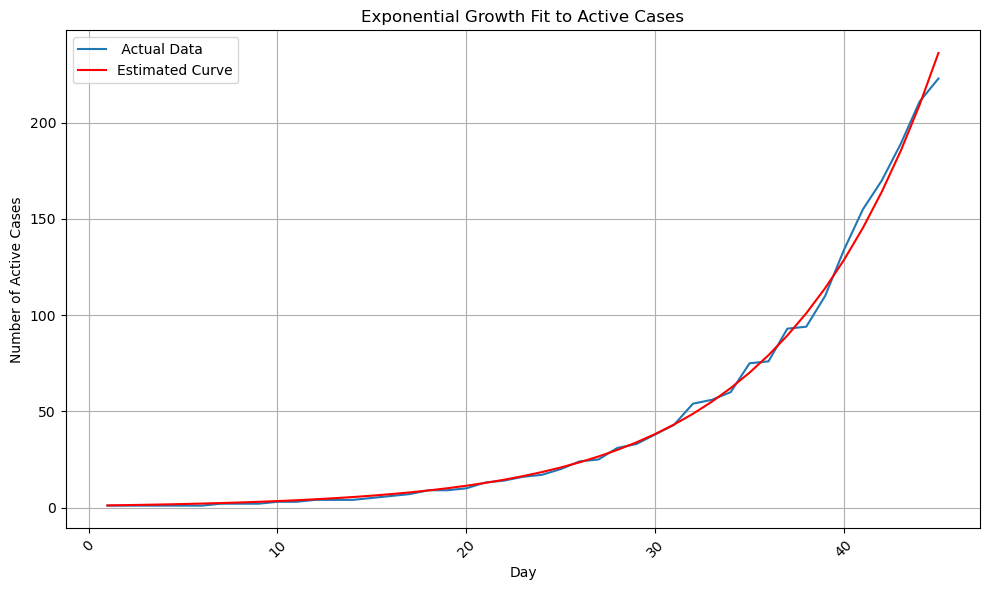

In [1]:
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = pd.read_csv('C:\\Users\\ajq2af\\OneDrive - University of Virginia\\Documents\\UVA\\BME 2315\\module2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Define a class to represent the virus data
#calculate the R0 value from early data csv file (first 45 days)
def eponential_growth(t,r):
    return np.exp(r*t)

x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(eponential_growth, x_data, y_data)
r_fit = popt[0]

D = 5 # estimated infection period from data 

r0 = np.exp(r_fit * D)

print("Estimated R0 value:", r0)
# add the fitted curve to the plot
y_fitted = eponential_growth(x_data, r_fit)
# plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label=' Actual Data')
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.title('Exponential Growth Fit to Active Cases')
plt.xlabel('Day')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

The estimated R0 value is 1.835. Other diseases that have a similar R0 value are Influenza (H1N1 2009) with an R0 value of 1.5 and Ebola with an R0 value of 2.0. The 2009 Influenza A strain was coined "swine flu" and spread rapidly throughout the globe through respiratory droplets. It had a relatively low fatality rate of 0.02% but was impactful enough that the World Health Organization declared a pandemic. While Ebola has a similar R0 value, it has a much higher ratality rate around 60%. It is transmitted through direct contact with infected bodily fluid and symptoms include fever, fatigue, vomiting/diarrhea, rash, and bleeding. Our R0 estimate at this stage is based on limited data, so it may not be accurate however it is a good estimate based on the data provided. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [2]:
#%% Euler's Method Approximation of SEIR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
data = pd.read_csv('C:\\Users\\ajq2af\\OneDrive - University of Virginia\\Documents\\UVA\\BME 2315\\module2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)

def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):  # function with inputs 
   # empty lists for S, E, I, R
    S = [] 
    E = []
    I = []
    R = []

    # set first item in each list to initial conditions 
    S.append(S0)
    E.append(E0)   
    I.append(I0)
    R.append(R0)

    # loop through timepoints to calculate the changes in S, E, I, R
    for t in range(len(timepoints) - 1):
        # derivatives for SEIR at time t
        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        # update S, E, I, R using Euler's method
        S_new = S[-1] + dS
        E_new = E[-1] + dE
        I_new = I[-1] + dI
        R_new = R[-1] + dR

        # append new values to lists
        S.append(S_new)
        E.append(E_new)
        I.append(I_new)
        R.append(R_new)
        
    return S, E, I, R


timepoints = data["day"].to_numpy() # timepoints are the day from the data
beta = 0.2 # I just put a random value here for now idk if that's right 
sigma = 0.083 # 12 days of incubation period
gamma = 0.14 # 7 days of infection 
# initial conditions from the data
N = 45
I0 = 1
S0 = 44
E0 = 0
R0 = 0
S, E, I, R = euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N)

print(S)
print(E)    
print(I)
print(R)

[44, 43.80444444444444, 43.63701412345679, 43.490426510698995, 43.35922161511344, 43.239295275068, 43.12755614226369, 43.02167187782523, 42.919880374484386, 42.820848774700764, 42.72356785309095, 42.627272700807836, 42.53138305089513, 42.43545831657313, 42.33916367770425, 42.242244479160824, 42.14450689165617, 42.04580329629538, 41.94602123535372, 41.845075057298125, 41.74289959839658, 41.6394454044599, 41.534675117679484, 41.42856074508478, 41.32108159424996, 41.2122227140748, 41.1019737179097, 40.990327896117755, 40.877281547722944, 40.76283347785917, 40.646984620649285, 40.529737756919225, 40.41109730355309, 40.29106915689975, 40.16966057688606, 40.04688010170712, 39.922737485400326, 39.79724365245603, 39.67041066501714, 39.542251699281, 39.41278102852194, 39.28201401076336, 39.14996707959237, 39.01665773696222, 38.88210454709601, 38.74632713080954, 38.609346159727075, 38.471183349983306, 38.33186145509639, 38.1914042577679, 38.049836560420445, 37.907184174326666, 37.76347390721749,

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [3]:
# Observed infected data
data_I = data["active reported daily cases"].to_numpy()

# parameter ranges for beta sigma and gamma
beta_range = np.linspace(0.01, 1, 30)
sigma_range = np.linspace(0.01, 1, 30)
gamma_range = np.linspace(0.01, 1, 30)

# create an empty list to store SSE values
SSE = []

# record best parameters
best_beta = None
best_sigma = None
best_gamma = None
best_SSE = np.inf

# Loop through parameter ranges
for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            # Run SEIR model
            S, E, I, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)

            # Convert model I values to numpy array and trim to data length
            I_model = np.array(I[:len(data_I)])

            # Calculate SSE
            sse = np.sum((data_I - I_model) ** 2)

            # Append to SSE list
            SSE.append(sse)

            # Check if this is the best fit
            if sse < best_SSE:
                best_SSE = sse
                best_beta = b
                best_sigma = s
                best_gamma = g

# Print results
print("best_beta:", best_beta)
print("best_sigma:", best_sigma)
print("best_gamma:", best_gamma)
print("SSE:", best_SSE)

best_beta: 0.21482758620689657
best_sigma: 0.21482758620689657
best_gamma: 0.01
SSE: 42998662.48690064


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Peak infections: 34.72768681300074
Peak occurs on day: 53


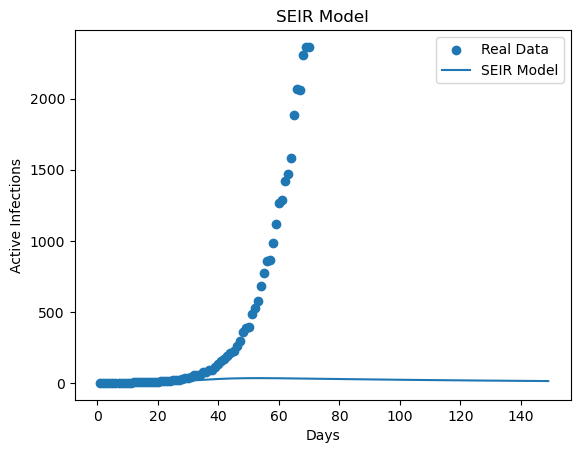

In [4]:
#%% use the best parameters to predict the future
future_days = 150
timepoints_future = np.arange(0, future_days)

S, E, I, R = euler_seir(best_beta, best_sigma, best_gamma,
                        S0, E0, I0, R0,
                        timepoints_future, N)

# Convert to numpy array
I = np.array(I)

# peak height of infections
peak_height = np.max(I)

# what day does the peak occur
peak_day = np.argmax(I)

print("Peak infections:", peak_height)
print("Peak occurs on day:", peak_day)

plt.figure()

# add the real data to the plot
plt.scatter(data["day"], data["active reported daily cases"], label="Real Data")

# add the model prediction to the plot
plt.plot(timepoints_future, I, label="SEIR Model")

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model")
plt.legend()

plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Peak infections: 34.72768681300074
Peak occurs on day: 53


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*